# Milestone 1 — PCR Lab Data

Eksploracyjna analiza logu zdarzeń z laboratorium PCR.
Źródło: [Zenodo #11617408](https://zenodo.org/records/11617408), kwiecień–czerwiec 2023.

Dane pochodzą z systemu CPEE (Cloud Process Execution Engine), który automatyzuje pracę laboratorium PCR. Każda próbka przechodzi kilka etapów: rejestracja, dopasowanie danych pacjenta, oczekiwanie na płytkę, odczyt wyniku. System loguje każde zdarzenie z czasem rozpoczęcia i zakończenia.

Jeden przebieg próbki = **case**. Jedno zdarzenie = pojedynczy wpis w logu procesu.

Surowy log: 6 339 case'ów, 317 905 zdarzeń. Ponad połowa to zdarzenia techniczne systemu. Po filtracji zostaje **134 099 zdarzeń biznesowych**.

In [1]:
# Pakiety sa w requirements.txt (instalacja poza notebookiem).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from urllib.parse import urlparse
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

ROOT = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = ROOT / 'results' / 'm1'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Dane
Przygotowane w (`00_etl.ipynb`).

In [3]:
df_events = pd.read_parquet(PROCESSED_DIR / 'pcr_events_biz.parquet')
df_cases = pd.read_parquet(PROCESSED_DIR / 'pcr_cases.parquet')

print(f'Zdarzenia biznesowe: {len(df_events):,}')
print(f'Cases: {len(df_cases):,}')
df_events.head(3)

Zdarzenia biznesowe: 134,099
Cases: 6,339


,case_id,instance_uuid,case_name,activity,endpoint,lifecycle,cpee_lifecycle,cpee_activity_id,cpee_state,timestamp,result,ct
0,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,timeout,https://mygreschner.com/backend/services/timeout2,start,activity/calling,a2,NaN,2023-05-02 14:17:41.174000+00:00,NaN,NaN
1,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Match patient data,https://mygreschner.com//backend/corr,start,activity/calling,a4,NaN,2023-05-02 14:17:41.185000+00:00,NaN,NaN
2,15143,003effb8-cb6d-468d-a243-a12763e5021c,Sample: 0cca00f1-183f-44a0-a132-b29ec7f34f6e,Wait for plate validation,https-get://cpee.org/ing/correlators/message/r...,start,activity/calling,a6,NaN,2023-05-02 14:17:41.186000+00:00,NaN,NaN


## Typy procesów

W logu widać dwa główne procesy:

| Proces | Co to | Ile case'ów | Zdarzeń na case |
|---|---|---:|---|
| **Sample** | Jedna próbka od rejestracji do wyniku | 6 166 | 10–12 |
| **Wellplate** | Zarządzanie jedną płytką (zbieranie próbek, PCR) | 167 | 64 – 31 838 |
| Lab Plain Instance | Cykl pracy laboratorium | 4 | 330 – 7 983 |
| Lab Finish Watcher | Zamykanie płytek | 2 | ~580 |

Dalej pracujemy tylko na **Sample**. Wellplate jest pomocniczy.

### Atrybuty

| Kolumna | Znaczenie | Typ danych | Status |
|---|---|---|---|
| `instance_uuid` | ID case'a | tekst (UUID) | kompletny |
| `activity` | Nazwa zdarzenia (np. "Match patient data") | tekst (kategoria) | 8 unikalnych typów |
| `timestamp` | Czas zdarzenia (UTC) | datetime | kompletny |
| `lifecycle` | `start` / `complete` | kategoria | kompletny |
| `pcr_result` | Wynik testu PCR | kategoria | brak dla 2.8% próbek |
| `ct` | Cycle threshold | liczba (float) | tylko POSITIVE |
| `endpoint` | Adres serwisu obsługującego zdarzenie | tekst (URI) | kompletny |

Brakuje: identyfikator osoby/urządzenia (kolumna `endpoint` to adresy serwisów, nie osób), koszty, priorytety.

In [4]:
print('Typy procesów:')
print(df_cases['process_type'].value_counts().to_string())
print()

df_samples = df_cases[df_cases['process_type'] == 'sample'].copy()
sample_ids = set(df_samples['instance_uuid'])
df_ev_samples = df_events[df_events['instance_uuid'].isin(sample_ids)].copy()

df_wellplate = df_cases[df_cases['process_type'] != 'sample'].copy()
wp_ids = set(df_wellplate['instance_uuid'])
df_ev_wp = df_events[df_events['instance_uuid'].isin(wp_ids)].copy()

print(f'Sample:    {len(df_samples):,} cases, {len(df_ev_samples):,} zdarzeń, {df_ev_samples["activity"].nunique()} typów zdarzeń')
print(f'Wellplate: {len(df_wellplate):,} cases, {len(df_ev_wp):,} zdarzeń, {df_ev_wp["activity"].nunique()} typów zdarzeń')
print()
print('Typy zdarzeń (sample):')
for a in sorted(df_ev_samples['activity'].unique()):
    print(f'  {a}')
print()
print('Typy zdarzeń tylko w wellplate:')
wp_only = set(df_ev_wp['activity'].unique()) - set(df_ev_samples['activity'].unique())
for a in sorted(wp_only):
    print(f'  {a}')

Typy procesów:
process_type
sample                6166
wellplate              165
lab_plain_instance       4
lab_finish_watcher       4

Sample:    6,166 cases, 65,584 zdarzeń, 8 typów zdarzeń
Wellplate: 173 cases, 68,515 zdarzeń, 23 typów zdarzeń

Typy zdarzeń (sample):
  Callback timeout
  Export result
  Export to EMS
  Match patient data
  Receive sample state
  Send notification
  Wait for plate validation
  timeout

Typy zdarzeń tylko w wellplate:
  Abandon spawned sample
  Check for Sample
  Check for unfinished Plates
  Delete: Wait for sample
  Delete: Wait for sample delete
  Finish wellplate
  Finish wellplate watcher
  Import EPS File
  New Wellplate
  Notify per wellplate subprocess
  Notify plain instance
  Receive finishids
  Send plate validation
  Sleep
  Spawn Single Wellplate
  Spawn per sample flow
  Stopping spawned sample
  Validate plate
  Wait for finished plate
  Wait for nudge
  Wait for sample
  Wait for sample delete 
  pop plateid


## Statystyki

In [5]:
min_ts = df_events['timestamp'].min()
max_ts = df_events['timestamp'].max()

endpoints_all = df_events['endpoint'].fillna('').astype(str)
endpoints_all = endpoints_all[endpoints_all != ''].nunique()

endpoints_sample = df_ev_samples['endpoint'].fillna('').astype(str)
endpoints_sample = endpoints_sample[endpoints_sample != ''].nunique()

print('--- Cały zbiór ---')
print(f'Cases:      {len(df_cases):>8,}')
print(f'Zdarzenia:  {len(df_events):>8,}')
print(f'Typy zdarzeń: {df_events["activity"].nunique():>6}')
print(f'Endpointy:  {endpoints_all:>8}')
print(f'Zakres: {min_ts.date()} -- {max_ts.date()} ({(max_ts - min_ts).days} dni)')

print()
print('--- Tylko sample ---')
print(f'Cases:      {len(df_samples):>8,}')
print(f'Zdarzenia:  {len(df_ev_samples):>8,}')
print(f'Typy zdarzeń: {df_ev_samples["activity"].nunique():>6}')
print(f'Endpointy:  {endpoints_sample:>8}')
print()
print('Zdarzeń na case (sample):')
print(df_samples['n_events'].describe().round(1).to_string())
print()
print('Czas trwania [min] (sample):')
print(df_samples['duration_min'].describe().round(1).to_string())

--- Cały zbiór ---
Cases:         6,339
Zdarzenia:   134,099
Typy zdarzeń:     31
Endpointy:        63
Zakres: 2023-04-02 -- 2023-06-14 (72 dni)

--- Tylko sample ---
Cases:         6,166
Zdarzenia:    65,584
Typy zdarzeń:      8
Endpointy:         8

Zdarzeń na case (sample):
count    6166.0
mean       10.6
std         1.9
min         3.0
25%        10.0
50%        10.0
75%        12.0
max        16.0

Czas trwania [min] (sample):
count    6166.0
mean      331.0
std       464.6
min         0.0
25%       158.0
50%       175.3
75%       260.6
max      5309.7


6166 próbek, 65 584 zdarzeń, 8 typów zdarzeń. Typowa próbka: 10 zdarzeń, ~3h od rejestracji do wyniku.

## Jakość danych

In [6]:
print('Brakujące wartości:')
for col in ['case_id', 'activity', 'timestamp', 'lifecycle', 'endpoint']:
    missing = df_events[col].isna().sum()
    print(f'  {col:<20}: {missing:>6,} ({100 * missing / len(df_events):.1f}%)')

dups = df_events.duplicated(subset=['instance_uuid', 'activity', 'lifecycle', 'timestamp']).sum()
no_result = df_samples['pcr_result'].isna().sum()
print(f'\nDuplikaty (uuid+activity+lifecycle+ts): {dups}')
print(f'Sample cases bez wyniku PCR: {no_result} ({100*no_result/len(df_samples):.1f}%)')

print('\n--- Kompletność lifecycle (sample) ---')
act_lc = df_ev_samples.groupby(['activity', 'lifecycle']).size().unstack(fill_value=0)
for act in act_lc.index:
    s = act_lc.loc[act, 'start'] if 'start' in act_lc.columns else 0
    c = act_lc.loc[act, 'complete'] if 'complete' in act_lc.columns else 0
    if s == 0 or c == 0:
        print(f'  {act:<30}: start={s}, complete={c}  <- niekompletne')
    elif abs(s - c) > s * 0.05:
        print(f'  {act:<30}: start={s}, complete={c}  <- różnica >5%')

Brakujące wartości:
  case_id             :      0 (0.0%)
  activity            :      0 (0.0%)
  timestamp           :      0 (0.0%)
  lifecycle           :      0 (0.0%)
  endpoint            :      0 (0.0%)

Duplikaty (uuid+activity+lifecycle+ts): 0
Sample cases bez wyniku PCR: 173 (2.8%)

--- Kompletność lifecycle (sample) ---
  Export result                 : start=821, complete=752  <- różnica >5%
  timeout                       : start=6168, complete=5731  <- różnica >5%


Kompletność: żadnych braków w kluczowych polach (ID, nazwa zdarzenia, czas, status). 173 próbek (2.8%) nie ma wyniku PCR.

Duplikaty: brak.

Chronologia: brak zdarzeń z niepoprawną kolejnością.

Typy danych: timestampy, liczby i teksty mają poprawne typy.

Pary start/complete: nie każde zdarzenie ma obie. `Send notification`, `Export to EMS`, `Export result` mają ~1-5% różnicy.

## Warianty procesu

In [7]:
starts = df_ev_samples[df_ev_samples['lifecycle'] == 'start'].sort_values(['instance_uuid', 'timestamp'])
traces = starts.groupby('instance_uuid')['activity'].apply(lambda x: ' -> '.join(x)).reset_index()
traces.columns = ['instance_uuid', 'trace']
variant_counts = traces['trace'].value_counts()

print(f'Unikalne warianty: {len(variant_counts)}')
print(f'Top 5 pokrywa: {100 * variant_counts.head(5).sum() / len(traces):.1f}% cases')
print(f'Top 10 pokrywa: {100 * variant_counts.head(10).sum() / len(traces):.1f}% cases')
print()

for i, (trace, count) in enumerate(variant_counts.head(10).items()):
    pct = 100 * count / len(traces)
    steps = trace.split(' -> ')
    short = ' -> '.join(a[:15] for a in steps)
    print(f'{i+1:>2}. [{count:>4} cases, {pct:>5.1f}%] ({len(steps)} steps): {short}')

Unikalne warianty: 122
Top 5 pokrywa: 66.8% cases
Top 10 pokrywa: 78.9% cases

 1. [1775 cases,  28.8%] (5 steps): timeout -> Match patient d -> Wait for plate  -> Receive sample  -> Callback timeou
 2. [1419 cases,  23.0%] (5 steps): timeout -> Wait for plate  -> Match patient d -> Receive sample  -> Callback timeou
 3. [ 427 cases,   6.9%] (5 steps): Match patient d -> timeout -> Wait for plate  -> Receive sample  -> Callback timeou
 4. [ 266 cases,   4.3%] (5 steps): Match patient d -> Wait for plate  -> timeout -> Receive sample  -> Callback timeou
 5. [ 229 cases,   3.7%] (5 steps): Wait for plate  -> timeout -> Match patient d -> Receive sample  -> Callback timeou
 6. [ 185 cases,   3.0%] (7 steps): timeout -> Match patient d -> Wait for plate  -> Receive sample  -> Export to EMS -> Export result -> Callback timeou
 7. [ 155 cases,   2.5%] (5 steps): Wait for plate  -> Match patient d -> timeout -> Receive sample  -> Callback timeou
 8. [ 137 cases,   2.2%] (6 steps): timeout -> 

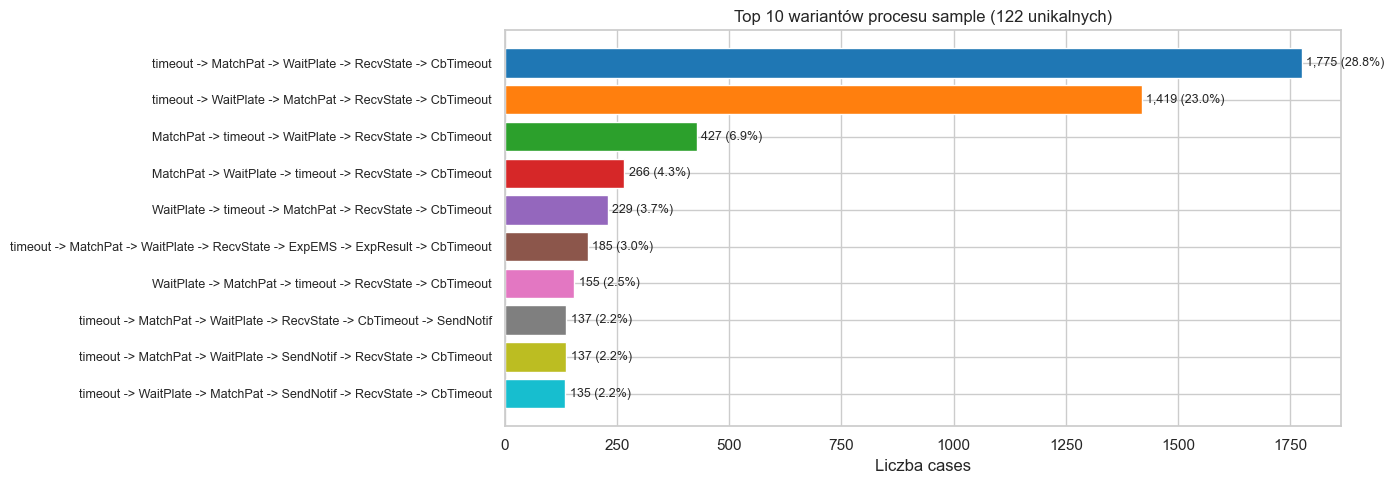

In [8]:
top_n = 10
top_variants = variant_counts.head(top_n)
labels = []
for trace in top_variants.index:
    steps = trace.split(' -> ')
    short = ' -> '.join(a.replace('Wait for plate validation', 'WaitPlate')
                         .replace('Match patient data', 'MatchPat')
                         .replace('Receive sample state', 'RecvState')
                         .replace('Callback timeout', 'CbTimeout')
                         .replace('Send notification', 'SendNotif')
                         .replace('Export to EMS', 'ExpEMS')
                         .replace('Export result', 'ExpResult')
                        for a in steps)
    labels.append(short)

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('tab10', top_n)
bars = ax.barh(range(top_n), top_variants.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels[::-1], fontsize=9)
for bar, val in zip(bars, top_variants.values[::-1]):
    pct = 100 * val / len(traces)
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Liczba cases')
ax.set_title(f'Top {top_n} wariantów procesu sample ({len(variant_counts)} unikalnych)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_variants.png', dpi=150, bbox_inches='tight')
plt.show()

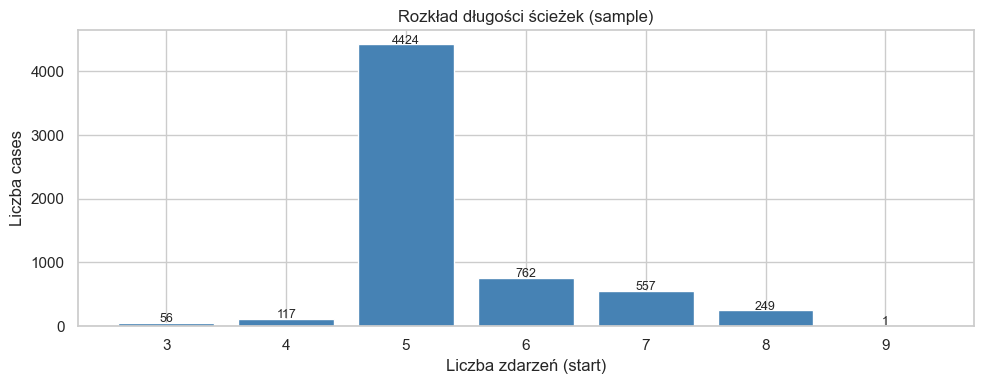

timeout -> Match patien -> Wait for pla -> Receive samp -> Callback tim:
  NEGATIVE: 1073
  POSITIVE: 702

timeout -> Wait for pla -> Match patien -> Receive samp -> Callback tim:
  NEGATIVE: 863
  POSITIVE: 555
  IPC: 1

Match patien -> timeout -> Wait for pla -> Receive samp -> Callback tim:
  NEGATIVE: 254
  POSITIVE: 173

Match patien -> Wait for pla -> timeout -> Receive samp -> Callback tim:
  NEGATIVE: 163
  POSITIVE: 103

Wait for pla -> timeout -> Match patien -> Receive samp -> Callback tim:
  NEGATIVE: 149
  POSITIVE: 80



In [9]:
traces_with_len = traces.copy()
traces_with_len['n_steps'] = traces_with_len['trace'].apply(lambda x: len(x.split(' -> ')))

fig, ax = plt.subplots(figsize=(10, 4))
step_counts = traces_with_len['n_steps'].value_counts().sort_index()
ax.bar(step_counts.index, step_counts.values, color='steelblue', edgecolor='white')
for x, y in zip(step_counts.index, step_counts.values):
    ax.text(x, y + 10, str(y), ha='center', fontsize=9)
ax.set_xlabel('Liczba zdarzeń (start)')
ax.set_ylabel('Liczba cases')
ax.set_title('Rozkład długości ścieżek (sample)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_trace_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

traces_merged = traces.merge(df_samples[['instance_uuid', 'pcr_result']], on='instance_uuid')
top5_traces = variant_counts.head(5).index
for trace in top5_traces:
    subset = traces_merged[traces_merged['trace'] == trace]
    results = subset['pcr_result'].value_counts(dropna=False)
    steps = trace.split(' -> ')
    short = ' -> '.join(a[:12] for a in steps)
    print(f'{short}:')
    for r, c in results.items():
        print(f'  {r}: {c}')
    print()

122 warianty, ale większość próbek idzie tą samą drogą. Top 2 = 52%, top 10 = 79%.

Główna ścieżka (~65% próbek, 5 zdarzeń):

| Zdarzenie | Co robi |
|---|---|
| `timeout` | Rejestracja próbki, start odliczania |
| `Match patient data` | Dopasowanie danych pacjenta |
| `Wait for plate validation` | Czekanie aż płytka się zapełni |
| `Receive sample state` | Odebranie wyniku PCR |
| `Callback timeout` | Zamknięcie procesu |

Drugi wariant (23%) to ta sama ścieżka z zamienioną kolejnością `timeout` i `Match patient data`.

## Ile trwa każde zdarzenie

In [10]:
sample_sorted = df_ev_samples.sort_values(['instance_uuid', 'cpee_activity_id', 'timestamp'])

starts_s = sample_sorted[sample_sorted['lifecycle'] == 'start'][
    ['instance_uuid', 'activity', 'cpee_activity_id', 'timestamp']].copy()
compl_s = sample_sorted[sample_sorted['lifecycle'] == 'complete'][
    ['instance_uuid', 'activity', 'cpee_activity_id', 'timestamp']].copy()

durations = starts_s.merge(compl_s, on=['instance_uuid', 'activity', 'cpee_activity_id'],
                           suffixes=('_start', '_complete'))
durations['duration_sec'] = (durations['timestamp_complete'] - durations['timestamp_start']).dt.total_seconds()

n_neg = (durations['duration_sec'] < 0).sum()
print(f'Ujemne czasy trwania (artefakty): {n_neg}')
durations = durations[durations['duration_sec'] >= 0]

dur_stats = durations.groupby('activity')['duration_sec'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']).round(1)
dur_stats = dur_stats.sort_values('count', ascending=False)
print()
print('Czas trwania zdarzeń [s]:')
print(dur_stats.to_string())

Ujemne czasy trwania (artefakty): 1

Czas trwania zdarzeń [s]:
                           count     mean   median      std     min       max
activity                                                                     
Wait for plate validation   6081  13051.4   9906.8  15707.7  7478.3  318065.8
Match patient data          6012    197.8      6.3   3756.8     0.0  158482.6
Receive sample state        5993    463.8     21.6   1346.8     0.4    9284.5
Callback timeout            5766      0.7      0.3      2.2     0.0      20.4
timeout                     5731  18216.4  10490.8  23973.7     0.0  171168.7
Send notification           1229      0.2      0.2      0.0     0.1       0.4
Export to EMS                798   7311.7    274.4  14637.0     0.8  140410.8
Export result                752   7183.3    321.8  13423.9     0.3  140410.8


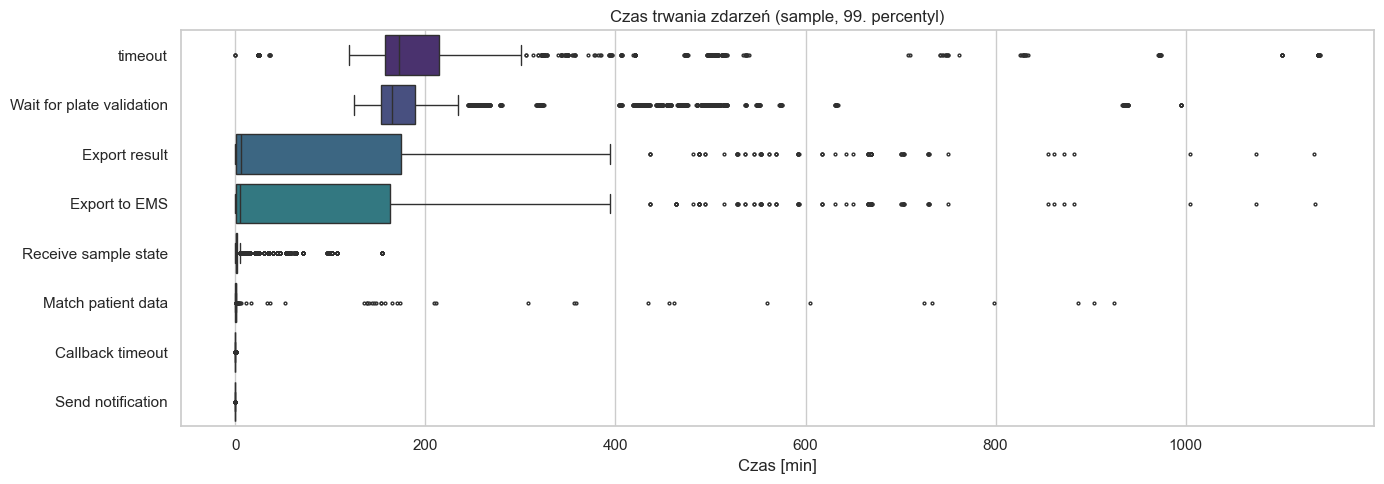

In [11]:
key_activities = ['timeout', 'Wait for plate validation', 'Match patient data',
                  'Receive sample state', 'Callback timeout', 'Send notification',
                  'Export to EMS', 'Export result']
dur_key = durations[durations['activity'].isin(key_activities)].copy()
dur_key['duration_min'] = dur_key['duration_sec'] / 60

p99 = dur_key['duration_min'].quantile(0.99)
dur_key_clip = dur_key[dur_key['duration_min'] <= p99]

fig, ax = plt.subplots(figsize=(14, 5))
order = dur_key_clip.groupby('activity')['duration_min'].median().sort_values(ascending=False).index
sns.boxplot(data=dur_key_clip, y='activity', x='duration_min', ax=ax, order=order,
            palette='viridis', fliersize=2)
ax.set_xlabel('Czas [min]')
ax.set_ylabel('')
ax.set_title('Czas trwania zdarzeń (sample, 99. percentyl)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_activity_durations.png', dpi=150, bbox_inches='tight')
plt.show()

Prawie cały czas próbki to czekanie na płytkę: zdarzenia `Wait for plate validation` (~165 min) i `timeout` (~175 min). Reszta (dopasowanie pacjenta, odbiór wyniku, zamknięcie) trwa sekundy. Eksporty wyników zwykle ~5 min, ale czasem dużo dłużej.

## Ile zdarzeń i ile czasu na próbkę

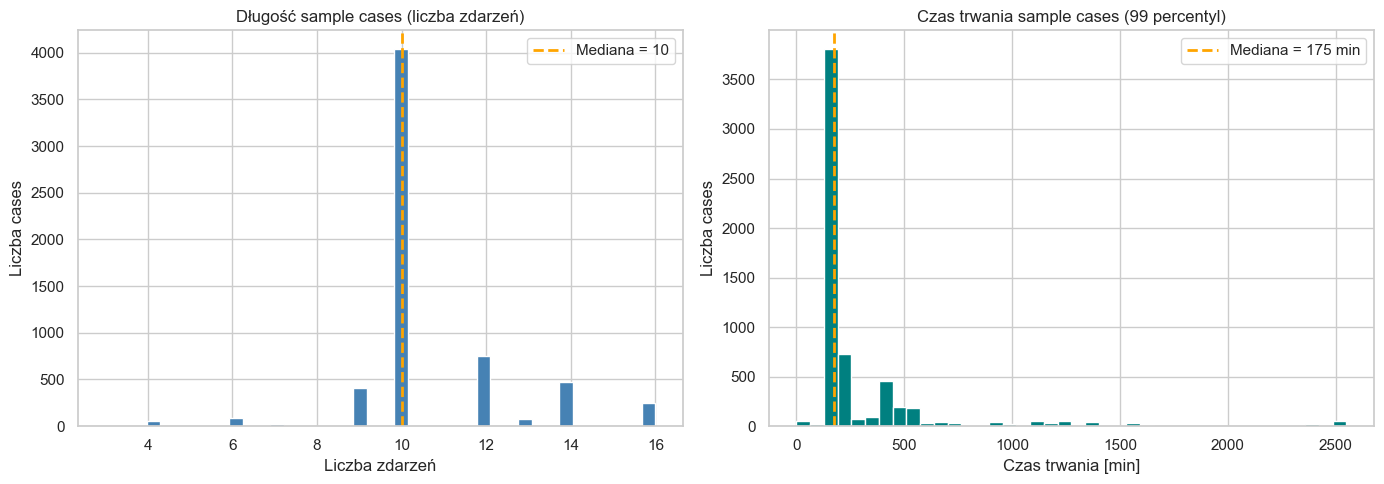

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

events_clipped = df_samples['n_events'].clip(upper=df_samples['n_events'].quantile(0.99))
axes[0].hist(events_clipped, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df_samples['n_events'].median(), color='orange', ls='--', lw=2,
                label=f'Mediana = {df_samples["n_events"].median():.0f}')
axes[0].set_xlabel('Liczba zdarzeń')
axes[0].set_ylabel('Liczba cases')
axes[0].set_title('Długość sample cases (liczba zdarzeń)')
axes[0].legend()

dur = df_samples['duration_min']
dur_clipped = dur[dur < dur.quantile(0.99)]
axes[1].hist(dur_clipped, bins=40, color='teal', edgecolor='white')
axes[1].axvline(dur_clipped.median(), color='orange', ls='--', lw=2,
                label=f'Mediana = {dur_clipped.median():.0f} min')
axes[1].set_xlabel('Czas trwania [min]')
axes[1].set_ylabel('Liczba cases')
axes[1].set_title('Czas trwania sample cases (99 percentyl)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_case_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Większość próbek ma 10 zdarzeń (5 typów zdarzeń z `start` + `complete`). Próbki z >12 mają dodatkowe eksporty/powiadomienia.

Czas: większość ok. 3h, ogon w prawo. Próbki >17h zapewne utknęły na noc.

## Jak często występują poszczególne zdarzenia

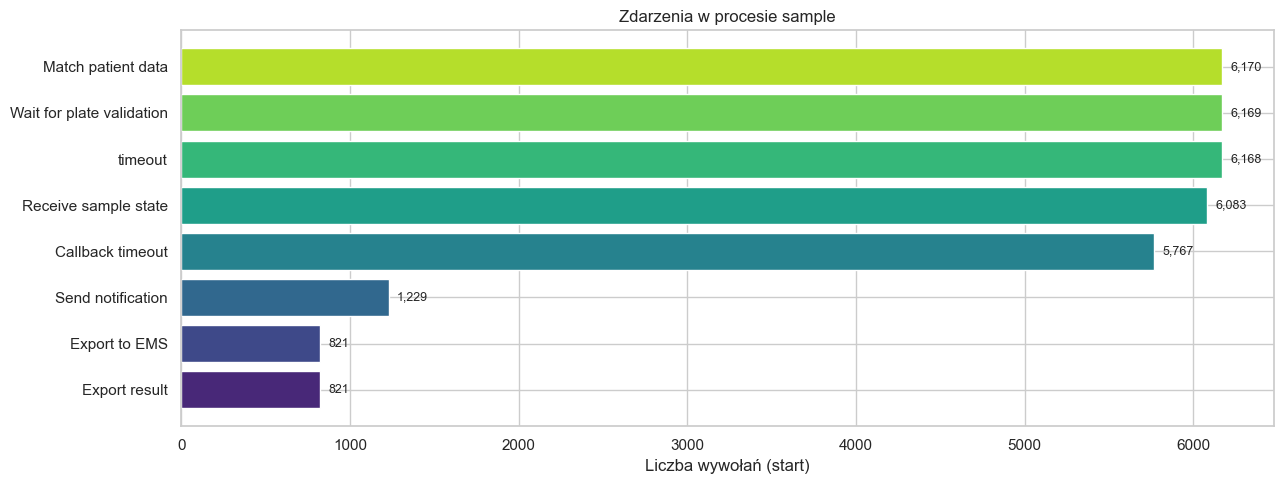

In [13]:
top_acts = (df_ev_samples[df_ev_samples['lifecycle'] == 'start']['activity']
            .value_counts())

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(top_acts.index[::-1], top_acts.values[::-1],
               color=sns.color_palette('viridis', len(top_acts)))
ax.set_xlabel('Liczba wywołań (start)')
ax.set_title('Zdarzenia w procesie sample')
for bar, val in zip(bars, top_acts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_top_activities.png', dpi=150, bbox_inches='tight')
plt.show()

5 głównych zdarzeń pojawia się ~6000 razy (raz na próbkę). Trzy dodatkowe — wysłanie powiadomienia (1229), eksport do EMS (921), eksport wyniku (824) — występują tylko w części próbek.

## Wyniki PCR i Ct

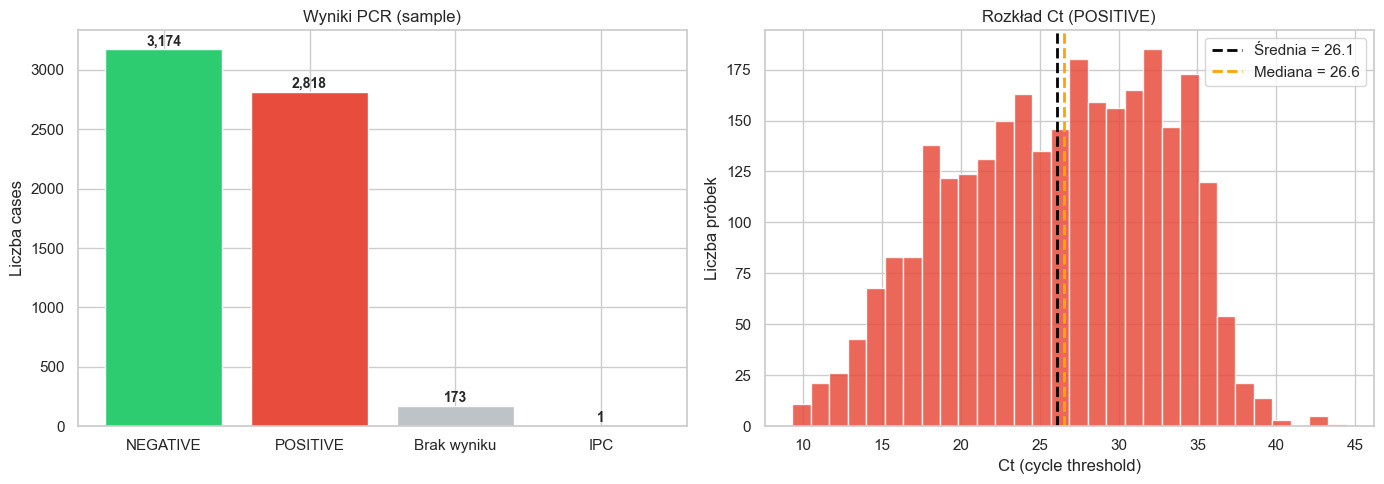

Próbki POSITIVE z Ct: 2,827
Ct: min=9.3, max=44.4, średnia=26.1, mediana=26.6


In [14]:
result_counts = df_samples['pcr_result'].value_counts(dropna=False)
result_counts.index = result_counts.index.where(result_counts.index.notna(), 'Brak wyniku')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_r = {'NEGATIVE': '#2ecc71', 'POSITIVE': '#e74c3c', 'IPC': '#f39c12', 'Brak wyniku': '#bdc3c7'}
bar_colors = [colors_r.get(x, '#95a5a6') for x in result_counts.index]
bars = axes[0].bar(result_counts.index, result_counts.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, result_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Liczba cases')
axes[0].set_title('Wyniki PCR (sample)')

ct_valid = df_samples['ct'].dropna()
axes[1].hist(ct_valid, bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].axvline(ct_valid.mean(), color='black', ls='--', lw=2,
                label=f'Średnia = {ct_valid.mean():.1f}')
axes[1].axvline(ct_valid.median(), color='orange', ls='--', lw=2,
                label=f'Mediana = {ct_valid.median():.1f}')
axes[1].set_xlabel('Ct (cycle threshold)')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_title('Rozkład Ct (POSITIVE)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_pcr_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Próbki POSITIVE z Ct: {len(ct_valid):,}')
print(f'Ct: min={ct_valid.min():.1f}, max={ct_valid.max():.1f}, średnia={ct_valid.mean():.1f}, mediana={ct_valid.median():.1f}')

Po odfiltrowaniu 173 próbek bez wyniku rozkład NEGATIVE/POSITIVE pozostaje zbliżony do 53/47. Ct (cycle threshold) dla próbek POSITIVE ma rozkład normalny ze średnią ~26.

## Heatmapa zdarzeń

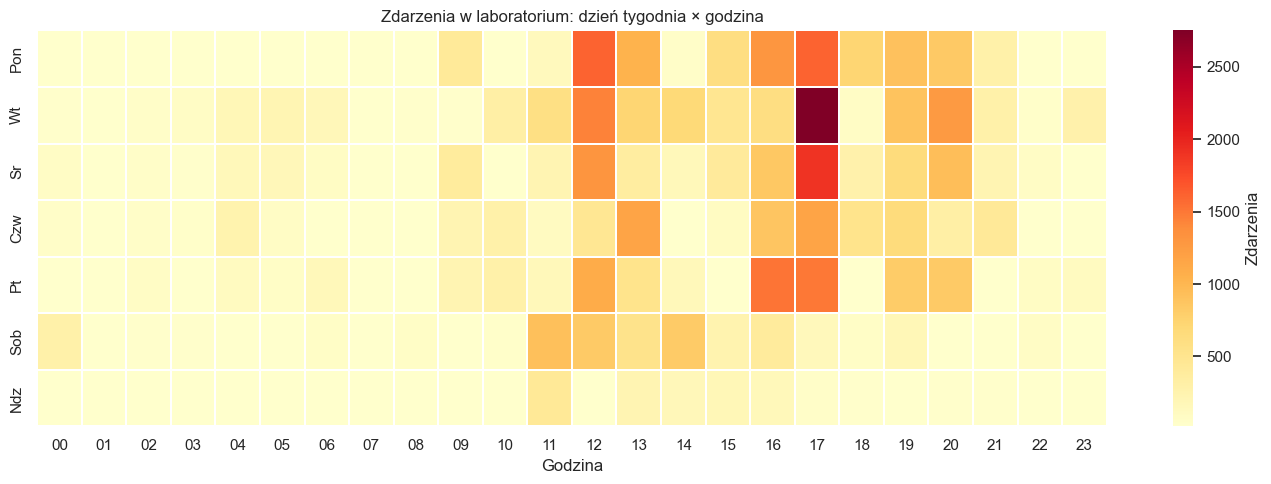

In [15]:
df_start = df_events[df_events['lifecycle'] == 'start'].copy()
df_start['hour'] = df_start['timestamp'].dt.hour
df_start['dayofweek'] = df_start['timestamp'].dt.dayofweek

heat_data = df_start.groupby(['dayofweek', 'hour']).size().unstack(fill_value=0)
day_names = ['Pon', 'Wt', 'Sr', 'Czw', 'Pt', 'Sob', 'Ndz']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_data, ax=ax, cmap='YlOrRd', linewidths=0.3,
            xticklabels=[f'{h:02d}' for h in range(24)],
            yticklabels=day_names,
            cbar_kws={'label': 'Zdarzenia'})
ax.set_xlabel('Godzina')
ax.set_ylabel('')
ax.set_title('Zdarzenia w laboratorium: dzień tygodnia × godzina')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_heatmap_activity.png', dpi=150, bbox_inches='tight')
plt.show()

Lab pracuje Pon–Pt ~11–21, najintensywniej Pon–Wt 12–18. W soboty trochę, niedziele prawie puste. Poniedziałkowo-wtorkowy peak może wynikać z nadrabiania po weekendzie.

## Timeline

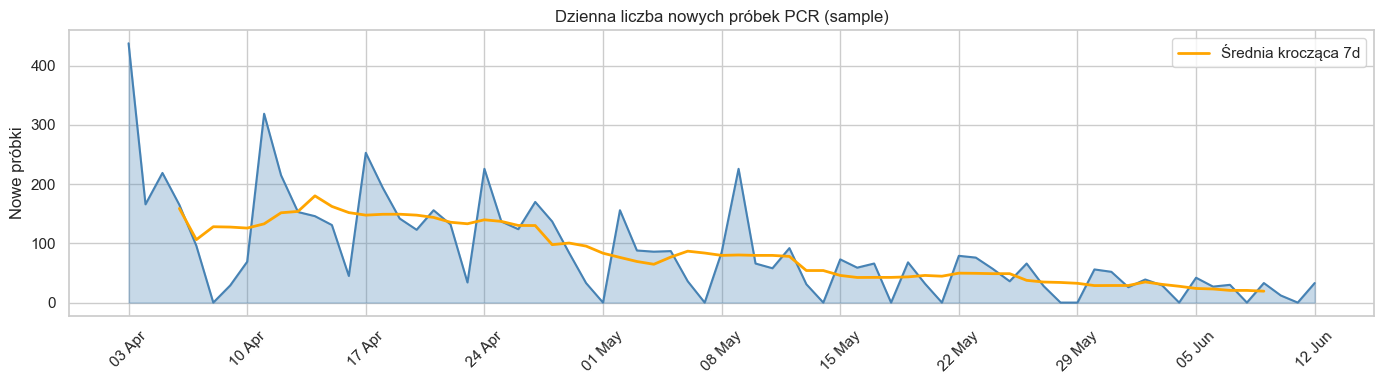

In [16]:
case_timeline = df_samples.set_index('first_ts').resample('D')['instance_uuid'].count()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(case_timeline.index, case_timeline.values, alpha=0.3, color='steelblue')
ax.plot(case_timeline.index, case_timeline.values, color='steelblue', lw=1.5)

rolling = case_timeline.rolling(7, center=True).mean()
ax.plot(rolling.index, rolling.values, color='orange', lw=2, label='Średnia krocząca 7d')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
ax.set_ylabel('Nowe próbki')
ax.set_title('Dzienna liczba nowych próbek PCR (sample)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

Początek kwietnia: >200 próbek dziennie. Koniec maja: ~50. Spadek + rytm tygodniowy (weekendy).

## Czy wynik PCR wpływa na czas przetwarzania

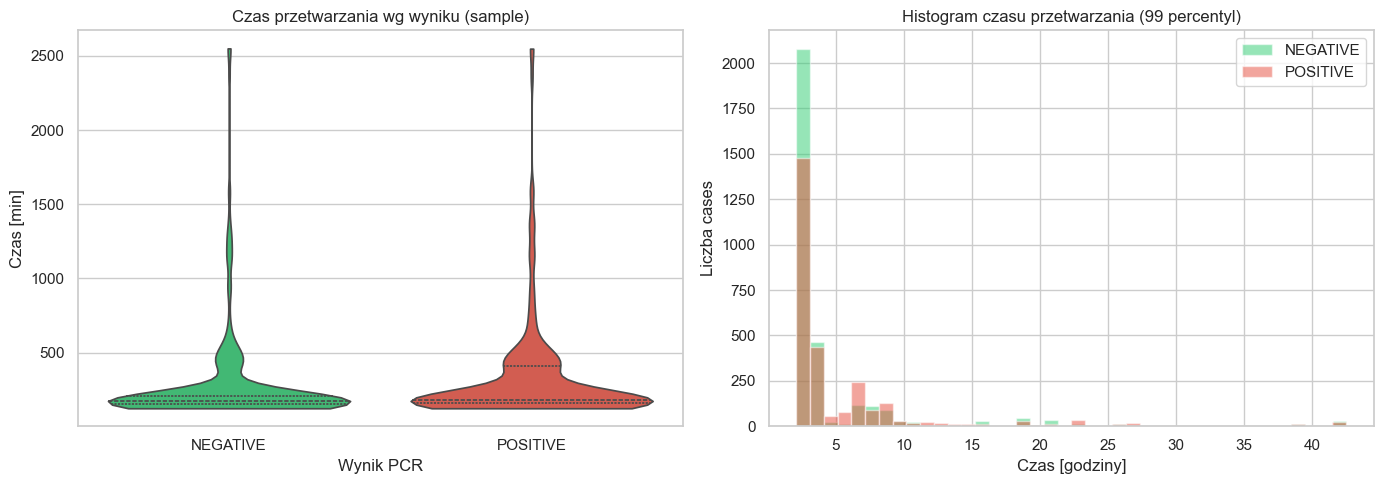

             count   mean    std    min    25%    50%    75%     max
pcr_result                                                          
NEGATIVE    3174.0  317.6  470.7  125.3  157.0  171.9  212.8  5308.9
POSITIVE    2818.0  357.3  467.6  125.4  161.9  182.9  420.0  5309.7


In [17]:
cs = df_samples[df_samples['pcr_result'].isin(['POSITIVE', 'NEGATIVE']) & (df_samples['duration_min'] > 0)].copy()
p99 = cs['duration_min'].quantile(0.99)
cs_clip = cs[cs['duration_min'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=cs_clip, x='pcr_result', y='duration_min', ax=axes[0],
               palette={'NEGATIVE': '#2ecc71', 'POSITIVE': '#e74c3c'},
               inner='quartile', cut=0)
axes[0].set_xlabel('Wynik PCR')
axes[0].set_ylabel('Czas [min]')
axes[0].set_title('Czas przetwarzania wg wyniku (sample)')

for result, color in [('NEGATIVE', '#2ecc71'), ('POSITIVE', '#e74c3c')]:
    vals = cs_clip.loc[cs_clip['pcr_result'] == result, 'duration_min'] / 60
    axes[1].hist(vals, bins=40, alpha=0.5, color=color, label=result, edgecolor='white')
axes[1].set_xlabel('Czas [godziny]')
axes[1].set_ylabel('Liczba cases')
axes[1].set_title('Histogram czasu przetwarzania (99 percentyl)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_duration_by_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(cs.groupby('pcr_result')['duration_min'].describe().round(1).to_string())

Rozkłady czasu dla NEGATIVE i POSITIVE prawie identyczne. POSITIVE minimalnie dłuższe (mediana ~183 vs ~172 min). Wynik PCR nie wpływa na czas.

## Endpointy (serwisy)

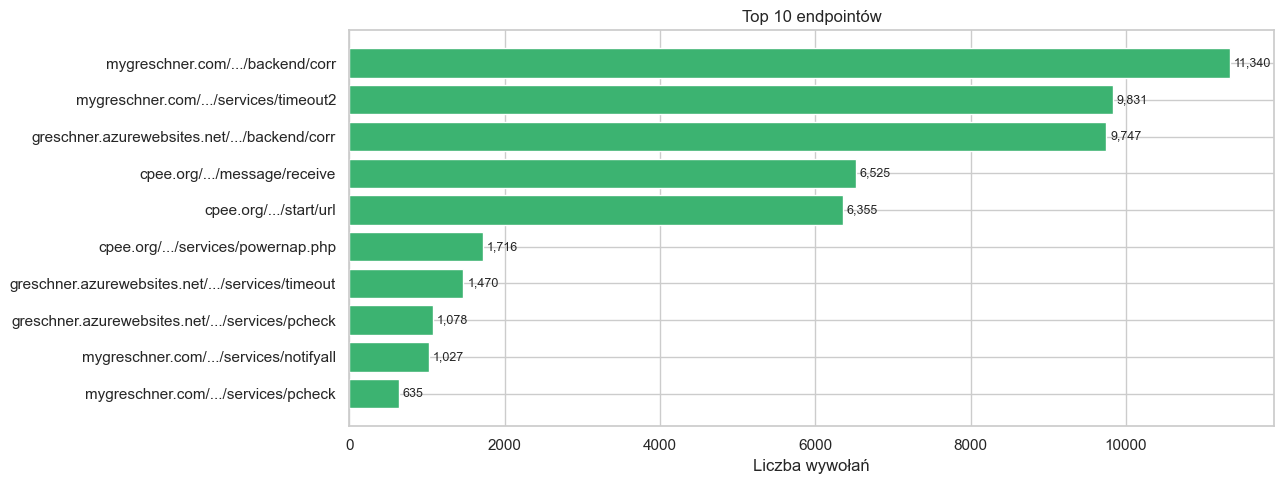

In [18]:
endpoint_counts = (df_events[df_events['lifecycle'] == 'start']['endpoint']
                   .value_counts())
endpoint_counts = endpoint_counts[endpoint_counts.index != ''].head(10)

def shorten_url(url):
    try:
        p = urlparse(url.replace('https-get://', 'https://').replace('https-post://', 'https://'))
        parts = [x for x in p.path.rstrip('/').split('/') if x]
        short = '/'.join(parts[-2:]) if len(parts) >= 2 else '/'.join(parts)
        return f'{p.hostname}/.../{short}'
    except Exception:
        return url[:50]

labels = [shorten_url(u) for u in endpoint_counts.index]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(labels[::-1], endpoint_counts.values[::-1],
               color='mediumseagreen', edgecolor='white')
for bar, val in zip(bars, endpoint_counts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Liczba wywołań')
ax.set_title('Top 10 endpointów')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_endpoints.png', dpi=150, bbox_inches='tight')
plt.show()

Łącznie 63 unikalne endpointy (adresy serwisów) w całym logu, a w procesie Sample: 8. Najczęstszy: `mygreshner.com/.../backend/corr` (11 340 wywołań). Endpointy to adresy serwisów, nie osób ani urządzeń.